# Preface
The goal of this exercise is to train a ResNet model to classify images of cat or dog. I am using **PyTorch** here, if you are using **TensorFlow**, it likely has methods that provide similar functionalities

In [ ]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from skimage.transform import resize

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Mount Google Drive to Colab
The first thing you need to do is upload the zip file to your Google Drive. Once you have done that, you can run the cell below

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Accept when prompted by Google Drive. If everything works well, you should see your Drive files and folders in the sidebar
<img src="https://raw.githubusercontent.com/aawihardja-usfca/phys303-hw4/refs/heads/main/click%20files.png" width=500>



# Extract zip files

In [ ]:
import zipfile

img_dir = '/content/drive/MyDrive/kagglecatsanddogs_5340.zip'

In [ ]:
def unzip_folder(src_path, dest_path):
  with zipfile.ZipFile(src_path, 'r') as myzip:
    myzip.extractall(dest_path)

In [ ]:
unzip_folder(img_dir, 'pet_images')

# Using Pytorch Dataset
I find that `Dataset` and `DataLoader` help with preprocessing the image. The `DataLoader` will process the image as needed (e.g. if `batch_size=128`, it will process 128 images at a time). In this manner, you save memory by not loading every images into memory.

There is one caveat though, I believe `Dataset` expects every index to be a valid one (it should return an image and its label). Because some image may be corrupted, we need to remove those images first so that `DataLoader` knows the number of samples in the dataset. This clean up is performed inside the `__init__` method.

Aside from the `__init__` method, we also need to override the `__getitem__` method. `DataLoader` will call `__getitem__` passing an index as parameter, so we need to return a tuple of (image tensor, label) that corresponds to the given index.

Read more on Dataset and DataLoader here https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset  

If you are feeling adventurous, PyTorch has a neat class called `ImageFolder` — maybe you can try it out. The name suggests that it does everything we need including:
  - loading image from a structured folder
  - applying transformation
  - it can even remove invalid images for you.

Read about it here https://pytorch.org/vision/0.16/generated/torchvision.datasets.ImageFolder.html

In [ ]:
class MyPetDataset(Dataset):
  def __init__(self, path, transform=None):
    super(MyPetDataset).__init__()
    self.image_files = []
    self.transform = transform
    for root, dirs, files in os.walk(path):
      for file in files:
        if file.endswith(".jpeg") or file.endswith(".jpg"):
          filename = os.path.join(root, file)
          try:
            with Image.open(filename) as img:
              img.verify()
            self.image_files.append(filename)
          except Exception as e:
            print(f'Failed to open file: {filename}, cause: {e}')

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, index):
    filename = self.image_files[index]
    image = Image.open(filename).convert('RGB')
    if self.transform:
      image = self.transform(image)
    else:
      # Resize using skimage if transform function is not provided
      image = resize(np.array(image), (64, 64), anti_aliasing=True)
      image = torch.tensor(np.array(image)).permute(2, 0, 1)
    label = 0 if 'Cat' in filename else 1
    return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

pet_dataset = MyPetDataset("pet_images/PetImages", transform=transform)

Failed to open file: pet_images/PetImages/Cat/666.jpg
Failed to open file: pet_images/PetImages/Dog/11702.jpg


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Split into train and test set

In [ ]:
train_ds, test_ds = random_split(pet_dataset, [0.9, 0.1])

Create DataLoader

In [ ]:
train_dataloader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_ds, batch_size=32, num_workers=2)

Verify the batch sizes

In [ ]:
train_iter = iter(train_dataloader)
X_train_samp, y_train_samp = next(train_iter)
assert X_train_samp.shape == (128, 3, 64, 64), "Expected (128, 3, 64, 64): 128 batch size, 3 channels, 64 x 64 pixels"
assert y_train_samp.shape == (128,), "Expected (128,)"
print(X_train_samp.shape)
print(y_train_samp.shape)

torch.Size([128, 3, 64, 64])
torch.Size([128])


In [ ]:
print(X_train_samp[5][0])

tensor([[0.3961, 0.4078, 0.4118,  ..., 0.4235, 0.4196, 0.4118],
        [0.4000, 0.4118, 0.4196,  ..., 0.4353, 0.4275, 0.4196],
        [0.4078, 0.4118, 0.4196,  ..., 0.4392, 0.4353, 0.4275],
        ...,
        [0.1608, 0.1843, 0.1843,  ..., 0.1216, 0.1216, 0.1216],
        [0.1804, 0.1765, 0.1882,  ..., 0.1255, 0.1490, 0.1333],
        [0.1765, 0.1608, 0.1647,  ..., 0.1373, 0.1373, 0.1373]])


# Display some images

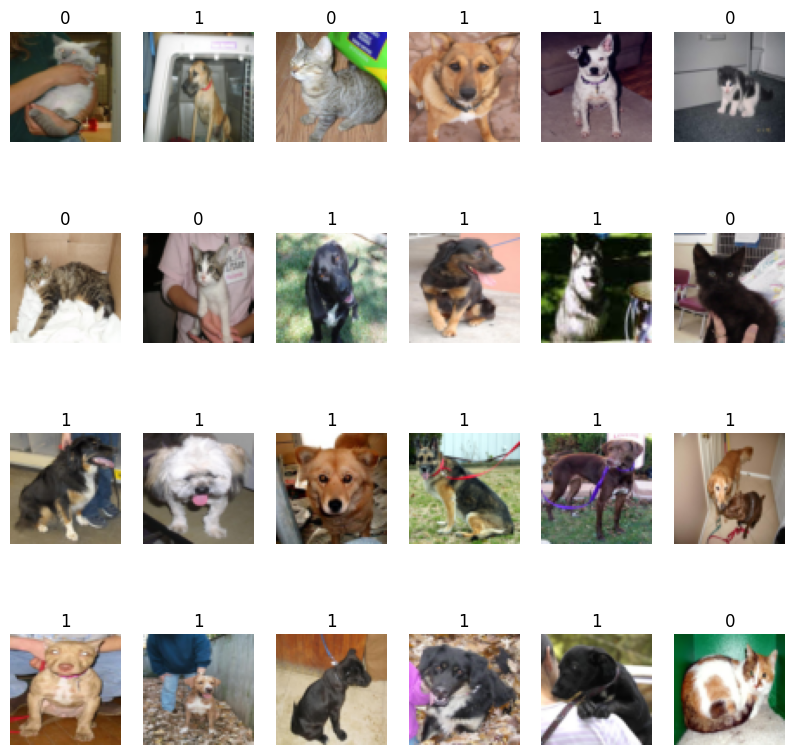

In [ ]:
fig, axs = plt.subplots(4, 6, figsize=(10, 10))

unnormalize = transforms.Normalize(mean=(-1, -1, -1), std=(2, 2, 2))

for i in range(4):
  for j in range(6):
    # img_tensor = unnormalize(X_train_samp[i*8 + j]).permute(1, 2, 0)
    img_tensor = X_train_samp[i*8 + j].permute(1, 2, 0)
    axs[i, j].imshow(img_tensor)
    axs[i, j].axis('off')
    axs[i, j].set_title(f'{y_train_samp[i*8 + j]}')